- overall work flow of this project - we query relevant data from influx - this includes the mppt temperature sensors ad vehicle velocity
- data to be queried from open meteo - every 15 minutes is irradiance, wind speed, ambient temperature
- curve fit to find relevant coefficients needed for the faiman model


From InfluxDB, query data over the first 4 days of FSGP 2025.

In [8]:
from data_tools import query
from data_tools.collections import TimeSeries
from datetime import datetime, date, time, timezone
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dill
import os

#each 5 seconds
utc_offset_h = 7
start_utc = time(12 , 00, 00) #querying is vancouver time, influxdb gives utc
stop_utc = time(00, 00, 00)
date_start = date(2025, 7, 2)
date_stop = date(2025, 7, 6)
start_time = datetime.combine(date_start, start_utc, tzinfo=timezone.utc)
stop_time = datetime.combine(date_stop, stop_utc, tzinfo=timezone.utc)

client = query.DBClient()
temp_array_fsgp: TimeSeries = client.query_time_series(start_time, stop_time, field=  "MosfetTemperatureA")
speed_kph: TimeSeries = client.query_time_series(start_time, stop_time, "MotorRotatingSpeed")


In [9]:
#save collected data of 15 minutes

import os
import dill

out_dir = os.path.join("../../motor_analysis", "data", "array_temperature_fsgp_2025-07-06")
mosfetA_file_aliter = os.path.join(out_dir, "mosfetA_aliter.bin")

os.makedirs(out_dir, exist_ok=True)

for filepath, data in zip([mosfetA_file_aliter],
                          [temp_array_fsgp]):
    with open(filepath, 'wb') as f:
        dill.dump(data, f)



#time zone matching conventions??

In [10]:
type(temp_array_fsgp)

data_tools.collections.time_series.TimeSeries

In [11]:
#convert to data frame
df_fsgp = pd.DataFrame(temp_array_fsgp)

querying from openmeteo to get solar irradiance data

- this is hourly irradiance over 4 days


In [12]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 36.9760,
	"longitude": 86.4491,
	"start_date": "2025-07-02",
	"end_date": "2025-07-06",
	"minutely_15": ["temperature_2m", "wind_speed_10m", "shortwave_radiation_instant"],
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_shortwave_radiation_instant = minutely_15.Variables(1).ValuesAsNumpy()
minutely_15_wind_speed_10m = minutely_15.Variables(2).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
	start = pd.to_datetime(minutely_15.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(minutely_15.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = minutely_15.Interval()),
	inclusive = "left"
)}

minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["shortwave_radiation_instant"] = minutely_15_shortwave_radiation_instant
minutely_15_data["wind_speed_10m"] = minutely_15_wind_speed_10m

minutely_15_dataframe = pd.DataFrame(data = minutely_15_data)
print("\nMinutely15 data\n", minutely_15_dataframe)

Coordinates: 37.0°N 86.5°E
Elevation: 5139.0 m asl
Timezone difference to GMT+0: 0s

Minutely15 data
                          date  temperature_2m  shortwave_radiation_instant  \
0   2025-07-02 00:00:00+00:00          -2.213                     5.588703   
1   2025-07-02 00:15:00+00:00          -2.163                     5.351785   
2   2025-07-02 00:30:00+00:00          -2.113                     5.014219   
3   2025-07-02 00:45:00+00:00          -2.063                     4.680000   
4   2025-07-02 01:00:00+00:00          -1.963                     4.680000   
..                        ...             ...                          ...   
475 2025-07-06 22:45:00+00:00          -1.263                    20.240196   
476 2025-07-06 23:00:00+00:00          -1.063                    19.881649   
477 2025-07-06 23:15:00+00:00          -0.963                    19.917469   
478 2025-07-06 23:30:00+00:00          -0.863                    19.959719   
479 2025-07-06 23:45:00+00:00          -

minutely open meteo data starts at 2 july, 12am and goes to 6 july 22 45
therefore on influx i query for 1 july 10  pm to 6 july 20 45


utc i s2 hours ahead of vancouver

Plot some relevant data. this will further be used to generate the relevant coefficients

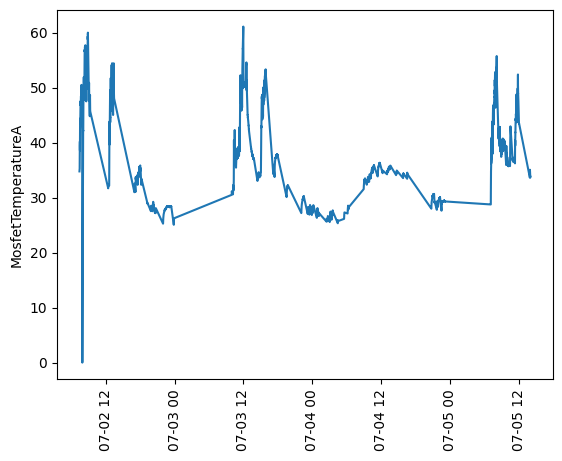

In [15]:
plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label = "Array Temperature")
plt.ylabel("MosfetTemperatureA")

plt.tick_params("x", rotation  = 90)

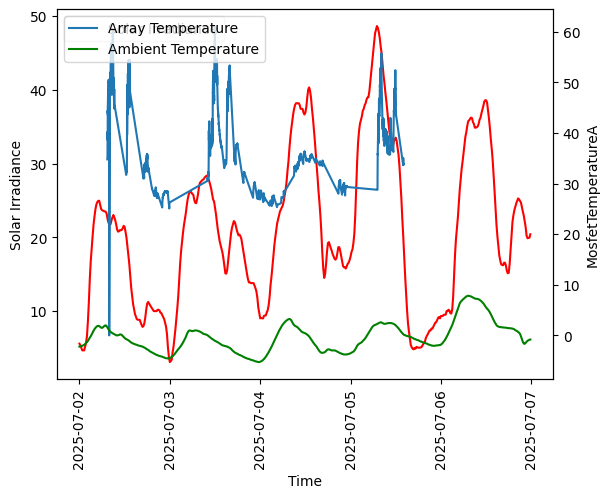

In [13]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)

fig, ax1 = plt.subplots()
ax_twin = ax1.twinx()

plt.plot(temp_array_fsgp.datetime_x_axis, temp_array_fsgp, label = "Array Temperature")
plt.plot(minutely_15_data['date'],minutely_15_data['temperature_2m'], color = 'green', label = "Ambient Temperature")
ax1.plot(minutely_15_data['date'],minutely_15_data['shortwave_radiation_instant'], color = "red", label = "Solar Irradiance")

ax1.set_xlabel("Time")
ax1.set_ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation  = 90)


plt.legend(loc = "upper left")
ax1.legend(loc = "upper left")
plt.show()

In [ ]:
#there really isn't Influx data for dates after midday 5 July, so I see no reason to incorporate the OpenMeteo data after

In [56]:
minutely_15_dataframe.head()
df_15min = minutely_15_dataframe[minutely_15_dataframe['date']<'2025-07-06']

In [57]:
df_15min.tail()
weather_df = df_15min.copy()

# Set datetime as index
weather_df["date"] = pd.to_datetime(weather_df["date"], utc=True)
weather_df = weather_df.set_index("date")
weather_df = weather_df.sort_index()


In [58]:
weather_df.head()

,temperature_2m,shortwave_radiation_instant,wind_speed_10m
date,,,
2025-07-02 00:00:00+00:00,-2.213,5.588703,124.831741
2025-07-02 00:15:00+00:00,-2.163,5.351785,164.539490
2025-07-02 00:30:00+00:00,-2.113,5.014219,205.015503
2025-07-02 00:45:00+00:00,-2.063,4.680000,243.104050
2025-07-02 01:00:00+00:00,-1.963,4.680000,276.808258


In [59]:
print("Influx 15min index:")
print(df_15m.index[:5])
print(df_15m.index[-5:])

print("Weather index:")
print(weather_df.index[:5])
print(weather_df[-5:])


Influx 15min index:
DatetimeIndex(['2025-07-02 07:15:00+00:00', '2025-07-02 07:30:00+00:00',
               '2025-07-02 07:45:00+00:00', '2025-07-02 08:00:00+00:00',
               '2025-07-02 08:15:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)
DatetimeIndex(['2025-07-05 13:00:00+00:00', '2025-07-05 13:15:00+00:00',
               '2025-07-05 13:30:00+00:00', '2025-07-05 13:45:00+00:00',
               '2025-07-05 14:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq=None)
Weather index:
DatetimeIndex(['2025-07-02 00:00:00+00:00', '2025-07-02 00:15:00+00:00',
               '2025-07-02 00:30:00+00:00', '2025-07-02 00:45:00+00:00',
               '2025-07-02 01:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='date', freq=None)
                           temperature_2m  shortwave_radiation_instant  \
date                                                                     
2025-07-05 22:45:00+00:00          -2.013                     8.49630

In [60]:
# Make sure indexes are sorted
df_15m_copy = df_15m.copy().sort_index()
weather_df = weather_df.sort_index()

# Force both onto exact 15-minute grid
df_15m_copy.index = df_15m_copy.index.floor("15T")
weather_df.index = weather_df.index.floor("15T")

# Keep only overlapping timestamps
common_index = df_15m_copy.index.intersection(weather_df.index)

print("Overlap start:", common_index.min())
print("Overlap end:", common_index.max())
print("Number of aligned points:", len(common_index))

# Merge on common timestamps
merged_df = pd.concat(
    [df_15m_copy.loc[common_index], weather_df.loc[common_index]],
    axis=1
)


Overlap start: 2025-07-02 07:15:00+00:00
Overlap end: 2025-07-05 14:00:00+00:00
Number of aligned points: 316


C:\Users\sanar\AppData\Local\Temp\ipykernel_14188\439453639.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m_copy.index = df_15m_copy.index.floor("15T")
C:\Users\sanar\AppData\Local\Temp\ipykernel_14188\439453639.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  weather_df.index = weather_df.index.floor("15T")


In [61]:
merged_df.head()

,value,temperature_2m,shortwave_radiation_instant,wind_speed_10m
2025-07-02 07:15:00+00:00,37.371079,1.787,23.177401,522.027100
2025-07-02 07:30:00+00:00,46.801625,1.487,22.406927,513.199951
2025-07-02 07:45:00+00:00,29.980004,1.137,21.945240,500.415741
2025-07-02 08:00:00+00:00,45.573409,0.887,21.817902,484.679749
2025-07-02 08:15:00+00:00,55.745558,0.687,21.767351,465.017517


In [62]:
merged_df.dropna()

,value,temperature_2m,shortwave_radiation_instant,wind_speed_10m
2025-07-02 07:15:00+00:00,37.371079,1.787,23.177401,522.027100
2025-07-02 07:30:00+00:00,46.801625,1.487,22.406927,513.199951
2025-07-02 07:45:00+00:00,29.980004,1.137,21.945240,500.415741
2025-07-02 08:00:00+00:00,45.573409,0.887,21.817902,484.679749
2025-07-02 08:15:00+00:00,55.745558,0.687,21.767351,465.017517
...,...,...,...,...
2025-07-05 13:00:00+00:00,38.086209,1.137,29.548521,58.205017
2025-07-05 13:15:00+00:00,36.774658,0.887,27.475807,22.902834
2025-07-05 13:30:00+00:00,35.463106,0.637,25.202570,2.313184
2025-07-05 13:45:00+00:00,34.271664,0.437,22.461807,0.000000


In [70]:
merged_df = merged_df.rename(columns = {'value':'array_temperature'})

In [71]:
merged_df.head()

,array_temperature,temperature_2m,shortwave_radiation_instant,wind_speed_10m
2025-07-02 07:15:00+00:00,37.371079,1.787,23.177401,522.027100
2025-07-02 07:30:00+00:00,46.801625,1.487,22.406927,513.199951
2025-07-02 07:45:00+00:00,29.980004,1.137,21.945240,500.415741
2025-07-02 08:00:00+00:00,45.573409,0.887,21.817902,484.679749
2025-07-02 08:15:00+00:00,55.745558,0.687,21.767351,465.017517


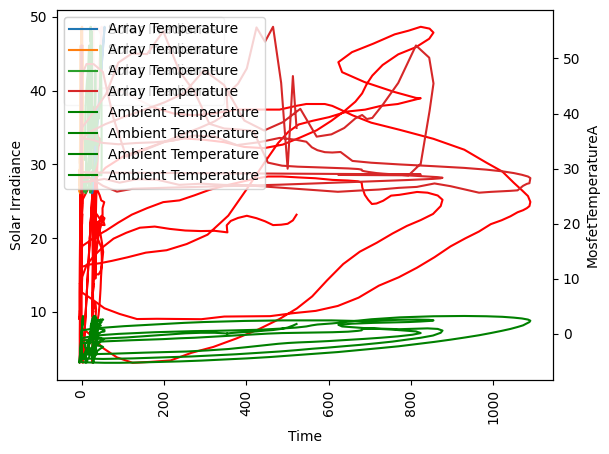

In [73]:
#this graph shows solar irradiance, array temperature, and ambient temperature over July 2-6 (FSGP 2025)



plt.plot(merged_df, merged_df['array_temperature'], label = "Array Temperature")
plt.plot(merged_df,merged_df['temperature_2m'], color = 'green', label = "Ambient Temperature")
plt.plot(merged_df,merged_df['shortwave_radiation_instant'], color = "red", label = "Solar Irradiance")

plt.xlabel("Time")
plt.ylabel("Solar Irradiance")
ax_twin.set_ylabel("MosfetTemperatureA")

ax1.tick_params("x", rotation  = 90)


plt.legend(loc = "upper left")
ax1.legend(loc = "upper left")
plt.show()

In [ ]:
#for easier access, im going to convert everything to a data frame after resampling.

In [38]:
import pandas as pd

#resampling influx data so that i can fit it with irradiance data (queried every 15 minutes)

ts = temp_array_fsgp
timestamps = pd.to_datetime(ts.datetime_x_axis, utc=True)
values = ts.data

df = pd.DataFrame({"value": values}, index=timestamps)
df_15m = df.resample("15T").mean()

print(df_15m.head())


                               value
2025-07-02 07:15:00+00:00  37.371079
2025-07-02 07:30:00+00:00  46.801625
2025-07-02 07:45:00+00:00  29.980004
2025-07-02 08:00:00+00:00  45.573409
2025-07-02 08:15:00+00:00  55.745558


C:\Users\sanar\AppData\Local\Temp\ipykernel_14188\1903960078.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_15m = df.resample("15T").mean()


In [39]:
merged_df = df_15m.join(df_15min, how="inner")


In [40]:
merged_df.head()

,value,date,temperature_2m,shortwave_radiation_instant,wind_speed_10m,array_temperature


In [35]:
len(df_15m)

316

In [34]:
df_15min.head(20)

,date,temperature_2m,shortwave_radiation_instant,wind_speed_10m,array_temperature
0,2025-07-02 00:00:00+00:00,-2.213,5.588703,124.831741,NaN
1,2025-07-02 00:15:00+00:00,-2.163,5.351785,164.539490,NaN
2,2025-07-02 00:30:00+00:00,-2.113,5.014219,205.015503,NaN
3,2025-07-02 00:45:00+00:00,-2.063,4.680000,243.104050,NaN
4,2025-07-02 01:00:00+00:00,-1.963,4.680000,276.808258,NaN
5,2025-07-02 01:15:00+00:00,-1.863,4.680000,309.431335,NaN
6,2025-07-02 01:30:00+00:00,-1.713,5.154415,344.148895,NaN
7,2025-07-02 01:45:00+00:00,-1.513,5.692100,386.145966,NaN
8,2025-07-02 02:00:00+00:00,-1.313,6.638072,440.518890,NaN
9,2025-07-02 02:15:00+00:00,-1.063,8.647496,500.905579,NaN


In [37]:
df_15min['array_temperature']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
379   NaN
380   NaN
381   NaN
382   NaN
383   NaN
Name: array_temperature, Length: 384, dtype: float64

In [36]:
#drop all NaN values
df_15min.dropna()

,date,temperature_2m,shortwave_radiation_instant,wind_speed_10m,array_temperature


import the Physics Array Temperature Model for validation/sanity checks


In [9]:
from v4.array_temperature.arrayTemperatureModel import arrayTemperatureModel
def model(u0, u1):
    return arrayTemperatureModel(minutely_15_dataframe['temperature_2m'], minutely_15_dataframe['shortwave_radiation_instant'], 0, u0, u1)

model = model(22, 0.8)
print(model.calculateArrayTemperature())


58.77777777777778
0     -1.958968
1     -1.919737
2     -1.885081
3     -1.850273
4     -1.750273
         ...   
475   -0.342991
476   -0.159289
477   -0.057661
478    0.044260
479    0.115122
Length: 480, dtype: float32


In [10]:
faiman_temp = model.calculateArrayTemperature()

In [11]:
import numpy as np
np.array(faiman_temp)

array([-1.9589682e+00, -1.9197371e+00, -1.8850808e+00, -1.8502727e+00,
       -1.7502728e+00, -1.6502727e+00, -1.4787085e+00, -1.2542682e+00,
       -1.0112695e+00, -6.6993195e-01, -2.5335747e-01,  1.8847007e-01,
        5.9909582e-01,  1.0304816e+00,  1.5046777e+00,  1.9256127e+00,
        2.2761874e+00,  2.5700946e+00,  2.7993662e+00,  2.9640732e+00,
        3.0212963e+00,  2.9718862e+00,  2.7955081e+00,  2.6217003e+00,
        2.5637720e+00,  2.6605344e+00,  2.8577871e+00,  3.0055342e+00,
        3.0537786e+00,  2.8405180e+00,  2.5054965e+00,  2.1345110e+00,
        1.8787228e+00,  1.6764250e+00,  1.6000929e+00,  1.4689474e+00,
        1.3838892e+00,  1.2705032e+00,  1.1520731e+00,  1.0254774e+00,
        9.4465721e-01,  9.8156601e-01,  1.0339725e+00,  1.1411557e+00,
        1.1396110e+00,  1.0429782e+00,  8.5300910e-01,  6.6731703e-01,
        4.6032685e-01,  2.7901125e-01,  1.4293087e-01, -8.7931752e-03,
       -1.6503155e-01, -3.7084109e-01, -5.9209096e-01, -8.1578338e-01,
      

In [87]:
len(faiman_temp)

120

In [90]:
df_15m.head()

,value
2025-07-02 07:15:00+00:00,37.371079
2025-07-02 07:30:00+00:00,46.801625
2025-07-02 07:45:00+00:00,29.980004
2025-07-02 08:00:00+00:00,45.573409
2025-07-02 08:15:00+00:00,55.745558


In [89]:
df_15m.tail()

,value
2025-07-05 13:00:00+00:00,38.086209
2025-07-05 13:15:00+00:00,36.774658
2025-07-05 13:30:00+00:00,35.463106
2025-07-05 13:45:00+00:00,34.271664
2025-07-05 14:00:00+00:00,34.174615


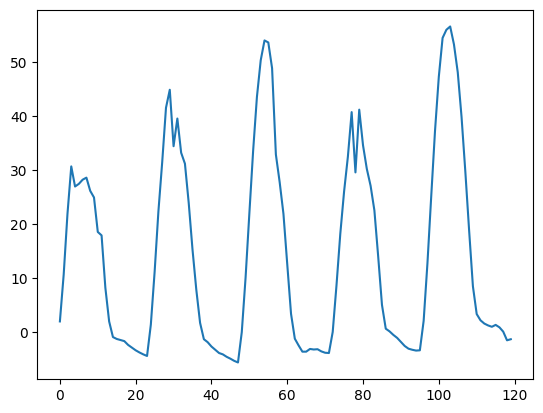

In [13]:
import numpy as np
from scipy.optimize import curve_fit

# Faiman model
def faiman_model(G, Ta, v, u0, u1):
    return Ta + G / (u0 + u1 * v)

def fit_faiman(G, Ta, v, T_array):
    popt, _ = curve_fit(
        lambda X, u0, u1: faiman_model(X[0], X[1], X[2], u0, u1),
        (G, Ta, v),
        T_array
    )
    return popt  # u0, u1


In [14]:
import matplotlib.pyplot as plt

def plot_comparison(df):
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()

    ax1.plot(df.index, df["irradiance"], label="Solar Irradiance", color="red")
    ax2.plot(df.index, df["value"], label="Array Temp")

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Irradiance (W/m²)")
    ax2.set_ylabel("Array Temperature (°C)")

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.xticks(rotation=90)
    plt.show()
